## Numpy

NumPy 是 Python 科学计算的基本库，提供多维数组对象、各种派生对象（如掩码数组和矩阵）以及一系列用于快速数组运算的例程，包括数学、逻辑、形状作、排序、选择、输入输出、离散傅里叶变换、基础线性代数、基础统计运算、随机仿真等。

In [1]:
import numpy as np

1.ravel：将多维数组展开为一维数组

详见：https://numpy.org/doc/stable/reference/generated/numpy.ravel.html

numpy.ravel(a, order='C')

order:{‘C’,’F’, ‘A’, ‘K’}
‘C’：行方向
‘F’：列方向
‘A’：若fortran连续（数组在内存中按列存储）则按列排布
‘K’：按内存中元素出现的顺序读取，但当 stride 为负时则不回转数据

In [2]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(arr)
arr =np.ravel(arr, order='C')
print(arr)

[[1 2 3]
 [4 5 6]]
[1 2 3 4 5 6]


In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(arr)
arr =np.ravel(arr, order='F')
print(arr)

In [ ]:
arr = np.array([[1,2,3],[4,5,6]])
print(arr.flags['F_CONTIGUOUS'])

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(arr)

arr_ravel = arr.ravel()
print(f"展平后的数组: {arr_ravel}") 

# 尝试修改展平后的数组
arr_ravel[0] = 10

# 检查原始数组是否也发生了变化
print(f"原始数组: {arr}") 

2.concatenate：连接多个数组

详见：https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html

numpy.concatenate((a1, a2, ...), axis=0, out=None, dtype=None, casting="same_kind")

In [ ]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6]])
np.concatenate((a, b), axis=0)

In [ ]:
np.concatenate((a, b.T), axis=1)

In [ ]:
np.concatenate((a, b), axis=None)

In [ ]:
np.concatenate([a,b])

3.clip：将一个np.array中的元素值限制在一个范围内

详见：https://numpy.org/doc/stable/reference/generated/numpy.clip.html

numpy.clip(a, a_min=<no value>, a_max=<no value>, out=None, *, min=<no value>, max=<no value>, **kwargs)

In [ ]:
a = np.arange(10)
print(a)

In [ ]:
b = np.clip(a, 1, 8)
print(b)

In [ ]:
b = np.clip(a, 8, 1)
print(b)

In [ ]:
np.clip(a, 3, 6, out=a) # 开启out参数可以更改原始数组的元素值
print(a)

In [ ]:
a = np.arange(10)
b = np.clip(a, [3, 4, 1, 1, 1, 4, 4, 4, 4, 4], 8) # 可以对每个元素设置不同的(min,max)
print(b)

4.interp：对单调递增采样点进行一维线性插值。

详见：https://numpy.org/doc/stable/reference/generated/numpy.interp.html

numpy.interp(x, xp, fp, left=None, right=None, period=None)

xp与fp：xp为一维数组（浮点），yp也为一维数组（浮点或复数），两者类似y=f(x)的函数的输入与输出，两者长度相同否则输出ValueError。

left与right：对应fp，指明当x<xp[0]或x>xp[-1]时的插值结果，默认为None，即使用fp[0]或fp[-1]。

period：若指定周期则left与right可以忽略。

In [ ]:
xp = [1, 2, 3]
fp = [3, 2, 0]
np.interp(2.5, xp, fp)

In [ ]:
np.interp([0, 1, 1.5, 2.72, 3.14], xp, fp)

In [ ]:
UNDEF = -99.0
np.interp(3.14, xp, fp, right=UNDEF)

In [ ]:
x = [-180, -170, -185, 185, -10, -5, 0, 365]
xp = [190, -190, 350, -350]
fp = [5, 10, 3, 4]
np.interp(x, xp, fp, period=360)

5.range Vs. np.arange Vs. np.linspace:Python中的等差数列数组

range为python的内置函数，用于生成一个整数序列。

语法为：range(start, end, step)

其中start为optinal，默认为0；end为required，结果并不会包含end值；sterp为optional，默认为1；所有变量均为整型。

np.arange为numpy中的函数，与range类似，但返回的是numpy数组。

语法为：numpy.arange([start, ]stop, [step, ]dtype=None, *, device=None, like=None)

对于整数参数，大致等价于Python内置的range函数，且并不会包含stop值；对于非整数步长，np.linspace更适合。

np.linspace也为numpy中的函数，与range类似，但返回的是numpy数组。

语法为：numpy.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0, *, device=None)

返回的数组元素类型为float64的浮点型。其中endpoint默认为True，表示包含stop值；retstep默认为False，表示是否返回步长；dtype为optional，表示输出数组的类型，若未给出则有start、stop、num给出，dtype永远不会为整型。

In [3]:
for n in range(3, 7, 2):
  print(n)

3
5


In [8]:
np.arange(3, 7, 2)

array([3, 5])

np.arange()在使用时的实际步长其实是dtype(start+step)-dtype(start)，因此当dtype与步长的类型不同时会出现精度丢失的问题，此时应该使用np.linspace()来避免该问题。

In [9]:
np.arange(0, 5, 0.5,dtype=int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [10]:
np.arange(0, 5, 0.5,dtype=float)

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5])

In [11]:
np.arange(-3, 3, 0.5, dtype=int)

array([-3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8])

内置的range函数生成具有任意大小的Python内置整数，而np.arange()则只能产生int32或int64类型的整数。

In [12]:
power = 40
modulo = 10000
x1 = [(n ** power) % modulo for n in range(8)]
x2 = [(n ** power) % modulo for n in np.arange(8)]
print(x1)
print(x2)

[0, 1, 7776, 8801, 6176, 625, 6576, 4001]
[0, 1, 0, 6897, 0, 3617, 0, 1537]


In [7]:
np.linspace(2.0, 12.0, num=5, endpoint=False, retstep=True, dtype=float)

(array([ 2.,  4.,  6.,  8., 10.]), 2.0)

6.np.reshape：

## Matplotlib

Matplotlib 是一个全面的库，用于用 Python 创建静态、动画和交互式可视化。

In [1]:
import matplotlib.pyplot as plt

1.add_grdispec：定义网格布局（相较于subplot_mosaic没那么常用）

详见：https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.add_gridspec.html

Figure.add_gridspec(nrows=1, ncols=1, **kwargs)

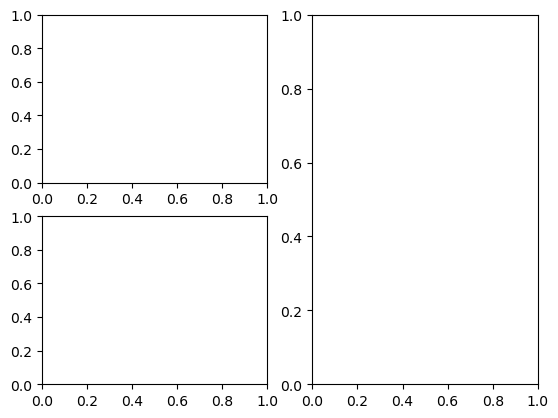

In [5]:
fig = plt.figure()
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
# spans two rows:
ax3 = fig.add_subplot(gs[:, 1])

2.subplot_mosaic：构建复杂的图片网格布局

详见：https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.subplot_mosaic.html

Figure.subplot_mosaic(mosaic, *, sharex=False, sharey=False, width_ratios=None, height_ratios=None, empty_sentinel='.', subplot_kw=None, per_subplot_kw=None, gridspec_kw=None)

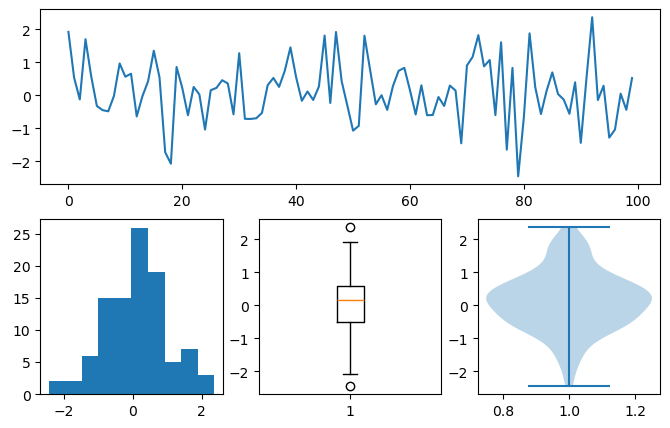

In [ ]:
raw_data = np.random.randn(100)
# 通过字符串定义布局
layout = """AAA
            BCD"""
fig, ax = plt.subplot_mosaic(layout, figsize=(8,5))
ax['A'].plot(raw_data)
ax['B'].hist(raw_data)
ax["C"].boxplot(raw_data)
ax["D"].violinplot(raw_data)
plt.show()

# layout="""ABC 
#           ABD"""
# layout="""ABC
#            A.D"""
# 配合  fig, ax = plt.subplot_mosaic(
#                           layout, figsize=(12, 8),
#                           gridspec_kw={"height_ratios": [1, 1.2], "hspace": 0.35}
#)控制子图之间间距

3.fill/fill_between：在图片中创建填充区域

In [ ]:
x = np.linspace(0, 5 * np.pi, 1000)
y1 = np.sin(x)
y2 = 2 * np.sin(x)
plt.fill(x, y1, color = "g", alpha = 0.3)

In [ ]:
plt.fill(np.concatenate([x, x[::-1]]),np.concatenate([y1, y2[::-1]]), color = "g", alpha = 0.3)
# 等价于
# plt.fill_between(x, y1, y2, color = "g", alpha = 0.3) 

## Pandas

Pandas 是一个开源、BSD 许可的库，为 Python 提供高性能、易用的数据结构和数据分析工具的编程语言。

In [ ]:
import pandas as pd